In [1]:
import os
from functools import partial
import pandas as pd
import equinox as eqx
import jax
jax.config.update("jax_default_matmul_precision", "highest")
# jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

## Ablation: Optimizer

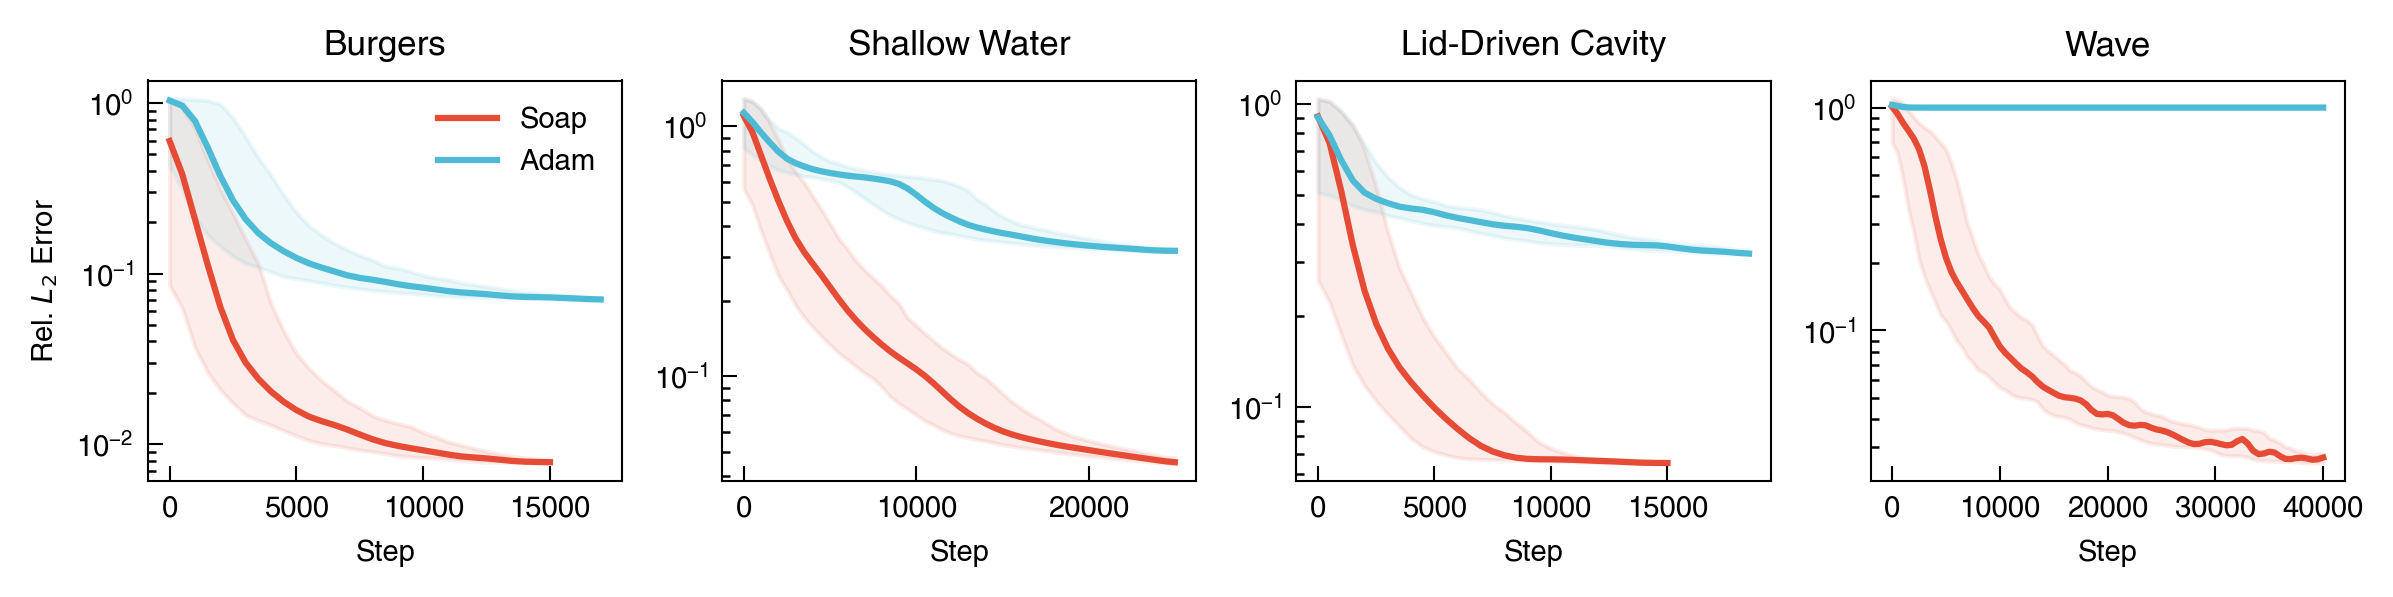

In [2]:
datasets = {
    "Burgers": [
        "training_logs/burgers/run-burgers_cvit_sota-nofilm-tag-eval_l2_error.csv",
        "training_logs/burgers/run-burgers_cvit_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Shallow Water": [
        "training_logs/swe/run-swe_cvit_SOTA-0217-tag-eval_l2_error.csv",
        "training_logs/swe/run-swe_cvit_ablation_adam-tag-eval_l2_error.csv",
    ],
    "Lid-Driven Cavity": [
        "training_logs/ldc/run-ldc_cvit_SOTA-0218-decdepth4-tag-eval_l2_error.csv",
        "training_logs/ldc/run-ldc_cvit_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Wave": [
        "training_logs/wave/run-wave_cvit_SOTA-decdim384-decdepth4-decheads12-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_cvit_ablation_adam-tag-eval_l2_error.csv",
    ]
}

tags = ["Soap", "Adam"]

from models.utils import smooth_loss_log_gaussian
fig, axes = plt.subplots(1, 4, figsize=(8, 2),)
axes = axes.flatten()
for idx, (name, paths) in enumerate(datasets.items()):
    ax = axes[idx]
    for j, (path, tag) in enumerate(zip(paths, tags)):
        df = pd.read_csv(path)
        val = df["Value"].values
        step = df["Step"].values
        mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.2, n_boot=1000)
        ax.fill_between(step, lower, upper, color=f"C{j}", alpha=0.1,)
        ax.plot(step, mean, label=tag, color=f"C{j}")

    ax.set(xlabel="Step", title=name,
           yscale="log")
    if idx == 0:
        ax.legend()
        ax.set(ylabel="Rel. $L_2$ Error")
        
fig.tight_layout()
# fig.savefig("./figures/ablation_optimizer.pdf", bbox_inches="tight", pad_inches=0.01)
# fig.savefig("./figures/ablation_optimizer.png", bbox_inches="tight", pad_inches=0.01, dpi=300)

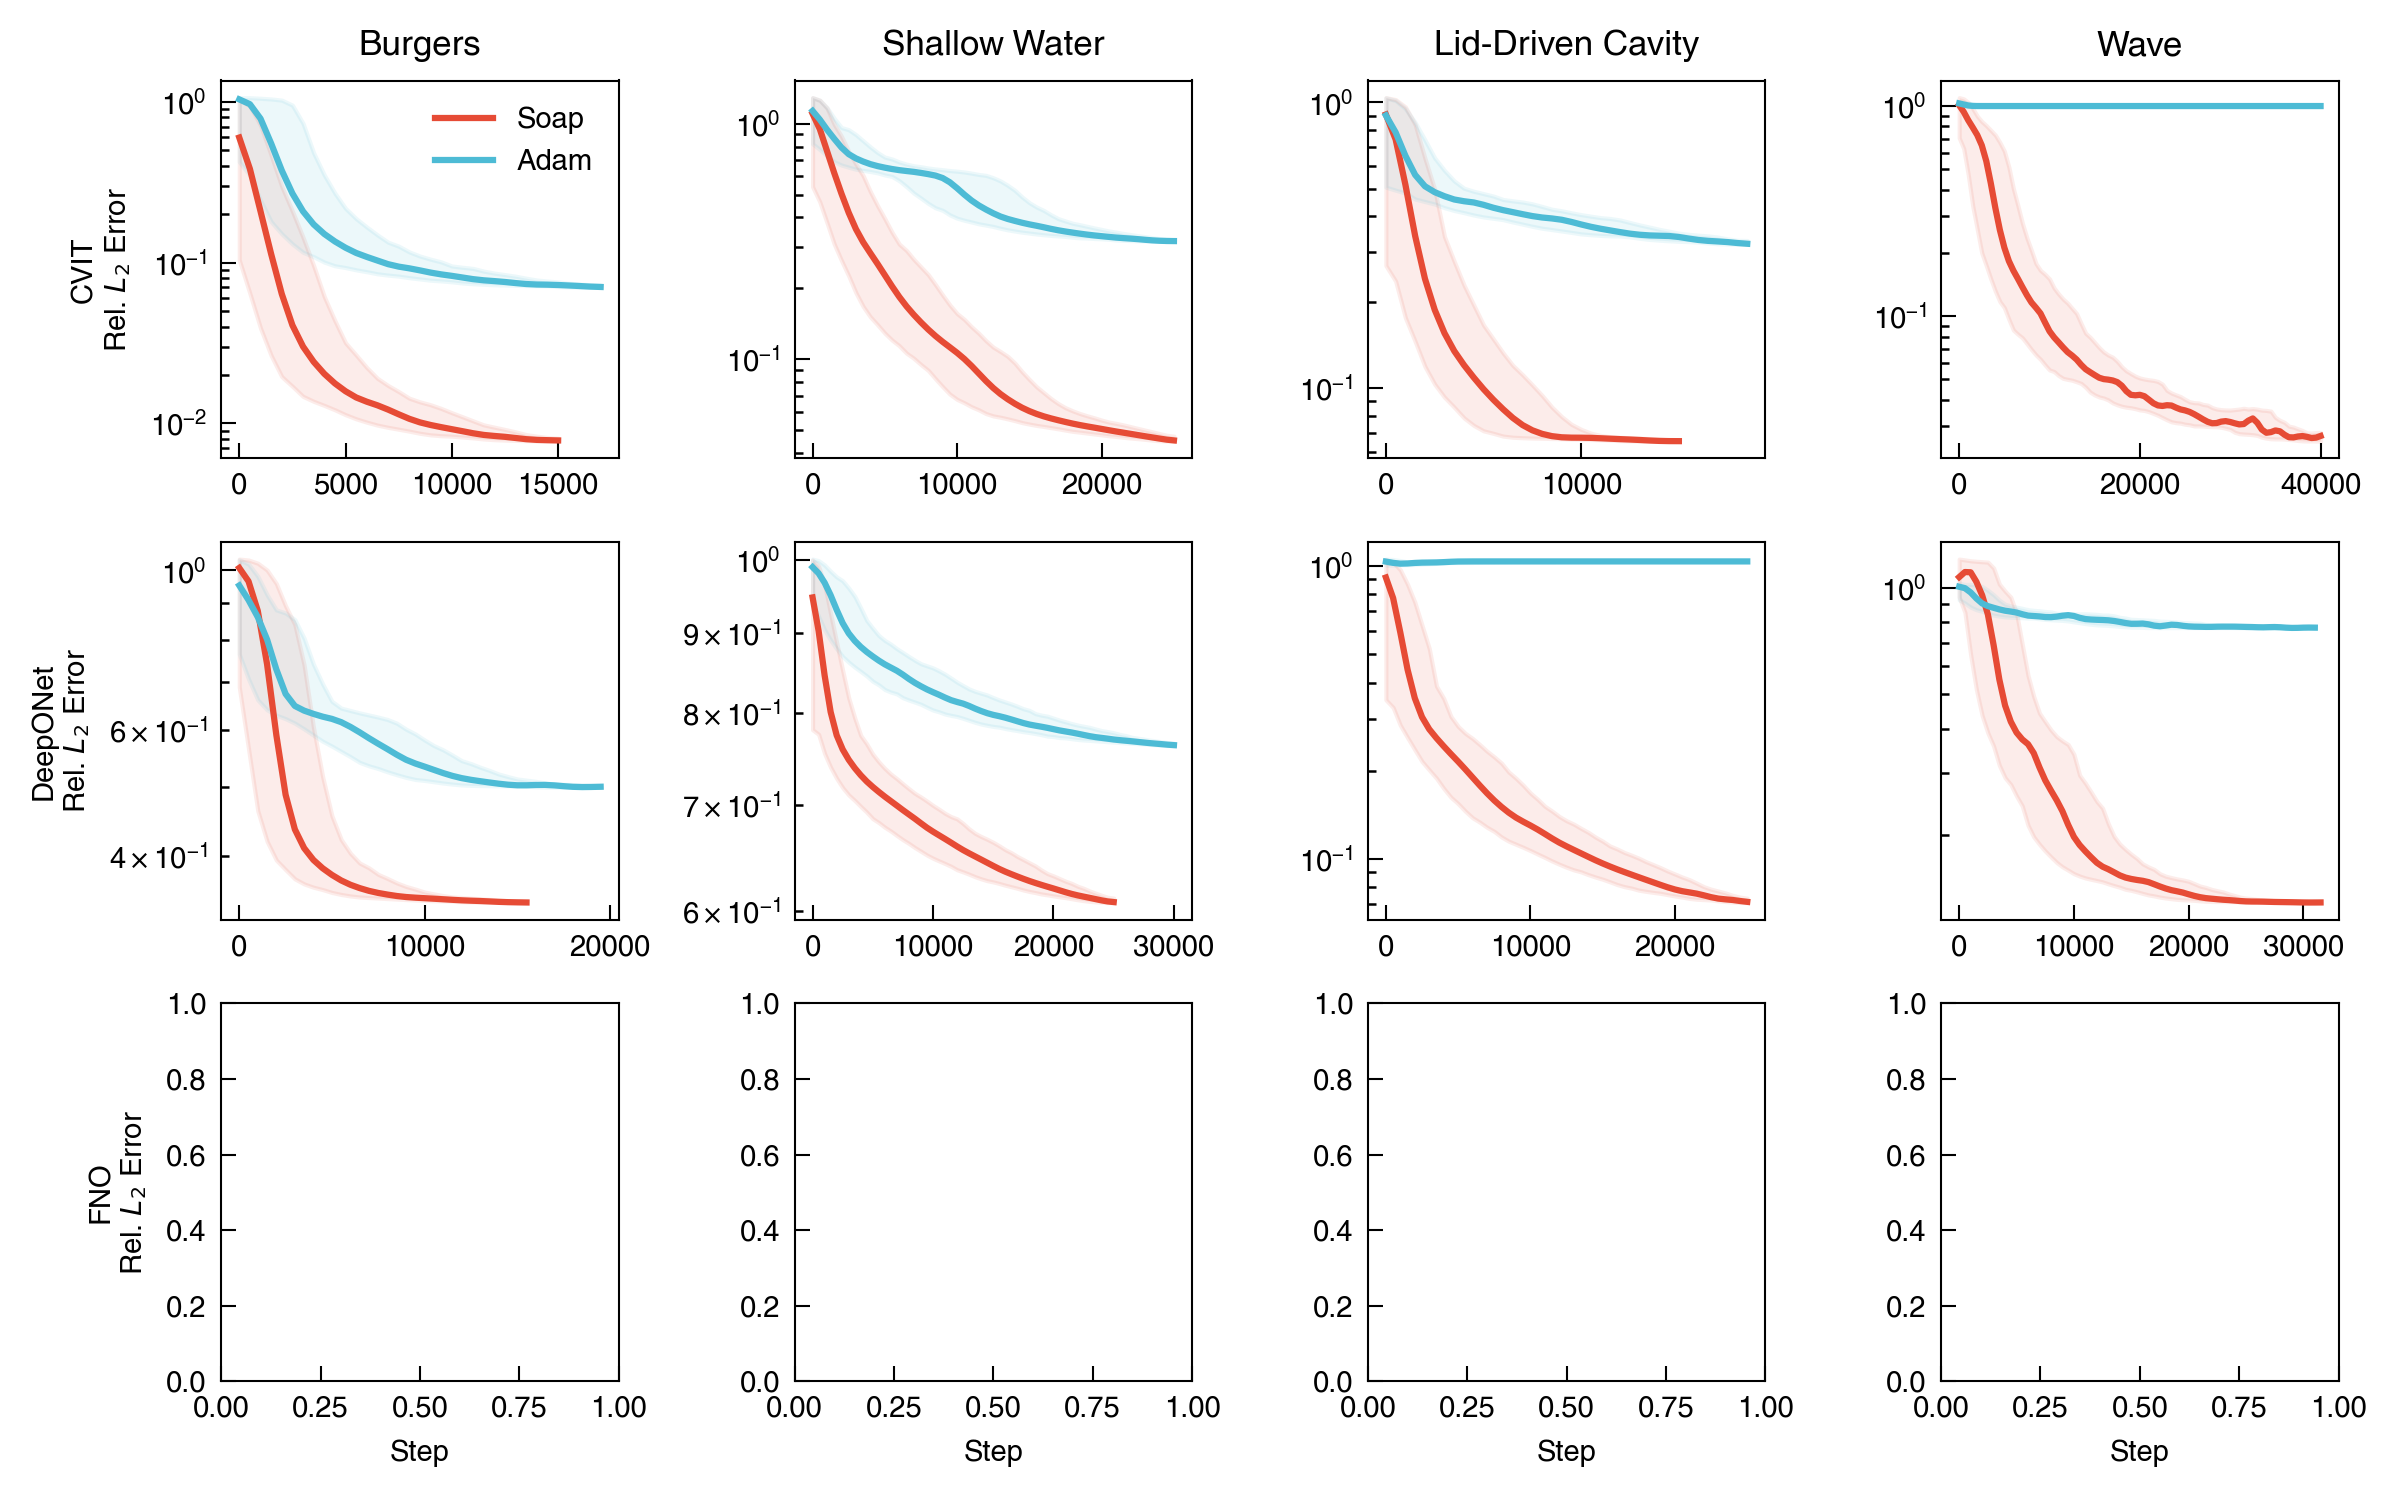

In [ ]:
cvit_ret = {
    "Burgers": [
        "training_logs/burgers/run-burgers_cvit_sota-nofilm-tag-eval_l2_error.csv",
        "training_logs/burgers/run-burgers_cvit_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Shallow Water": [
        "training_logs/swe/run-swe_cvit_SOTA-0217-tag-eval_l2_error.csv",
        "training_logs/swe/run-swe_cvit_ablation_adam-tag-eval_l2_error.csv",
    ],
    "Lid-Driven Cavity": [
        "training_logs/ldc/run-ldc_cvit_SOTA-0218-decdepth4-tag-eval_l2_error.csv",
        "training_logs/ldc/run-ldc_cvit_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Wave": [
        "training_logs/wave/run-wave_cvit_SOTA-decdim384-decdepth4-decheads12-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_cvit_ablation_adam-tag-eval_l2_error.csv",
    ]
}
deeponet_ret = {
    "Burgers": [
        "training_logs/burgers/run-burgers_deeponet_baseline-0219-tag-eval_l2_error.csv",
        "training_logs/burgers/run-burgers_deeponet_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Shallow Water": [
        "training_logs/swe/run-swe_deeponet_baseline-tag-eval_l2_error.csv",
        "training_logs/swe/run-swe_deeponet_adam-tag-eval_l2_error.csv"
    ],
    "Lid-Driven Cavity": [
        "training_logs/ldc/run-ldc_deeponet_baseline-tag-eval_l2_error.csv",
        "training_logs/ldc/run-ldc_deeponet_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Wave": [
        "training_logs/wave/run-wave_deeponet_baseline-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_deeponet_ablation_adam-tag-eval_l2_error.csv",
    ]
}
fno_ret = {
    "Burgers": [
    ],
    "Shallow Water": [
    ],
    "Lid-Driven Cavity": [
    ],
    "Wave": [
    ]
}

tags = ["Soap", "Adam"]
model_names = ["CVIT", "DeepONet", "FNO"]


from models.utils import smooth_loss_log_gaussian
fig, axes = plt.subplots(3, 4, figsize=(8, 5),)
# axes = axes.flatten()
for model_id, dataset in enumerate([cvit_ret, deeponet_ret, fno_ret]):

    for example_idx, (name, paths) in enumerate(dataset.items()):
        ax = axes[model_id, example_idx]
        
        if example_idx == 0:
            ax.set_ylabel(f"{model_names[model_id]}\nRel. $L_2$ Error")
            # ax.text(-0.2, 0.5, model_names[model_id], 
            #         va="center", ha="center", rotation=90, transform=ax.transAxes)

        if model_id == 0:
            ax.set_title(name)
        if model_id == 2:
            ax.set_xlabel("Step")
            
        if len(paths) == 0:
            continue
            
        for j, (path, tag) in enumerate(zip(paths, tags)):
            df = pd.read_csv(path)
            val = df["Value"].values
            step = df["Step"].values
            mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.2, n_boot=1000)
            ax.fill_between(step, lower, upper, color=f"C{j}", alpha=0.1,)
            ax.plot(step, mean, label=tag, color=f"C{j}")
        ax.set_yscale("log")
        
        if model_id == 0 and example_idx == 0:
            ax.legend()
fig.tight_layout()


## Ablation: FiLM-conditioning

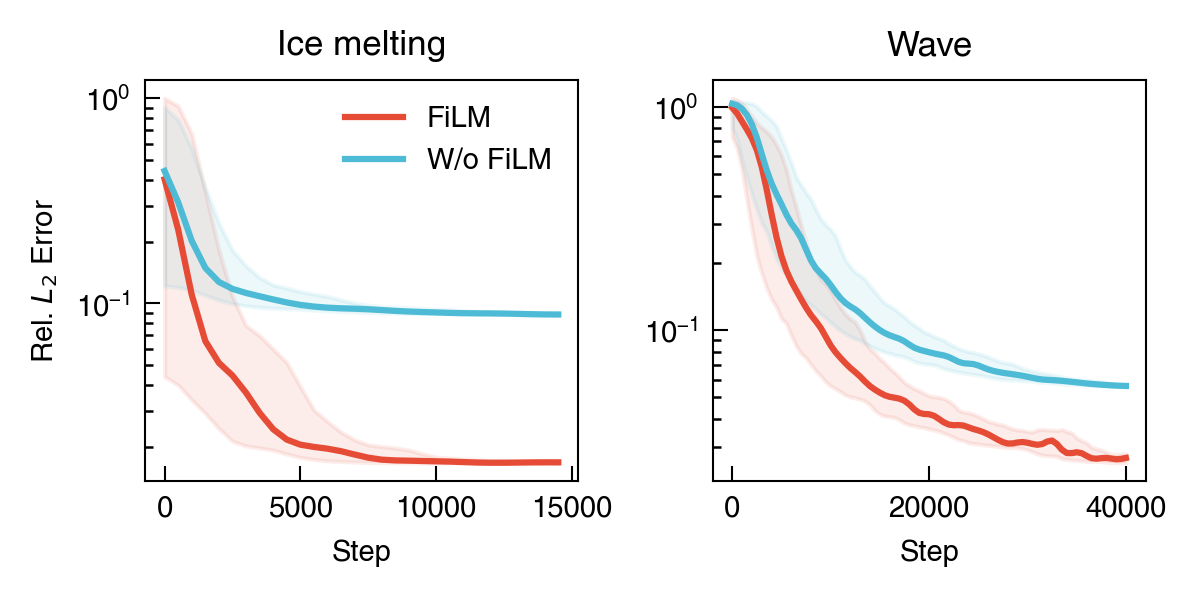

In [4]:
datasets = {
    "Ice melting": [
        "training_logs/ice_melting/run-ice_melting_ellipse_cvit_sota-0121-tag-eval_l2_error.csv",
        "training_logs/ice_melting/run-ice_melting_ellipse_cvit_no-film-tag-eval_l2_error.csv"
    ],
    "Wave": [
        "training_logs/wave/run-wave_cvit_SOTA-decdim384-decdepth4-decheads12-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_cvit_SOTA-nofilm-tag-eval_l2_error.csv"
    ]
}

tags = ["FiLM", "W/o FiLM"]
fig, axes = plt.subplots(1, 2, figsize=(4, 2),)
axes = axes.flatten()
for idx, (name, paths) in enumerate(datasets.items()):
    ax = axes[idx]
    for j, (path, tag) in enumerate(zip(paths, tags)):
        df = pd.read_csv(path)
        val = df["Value"].values
        step = df["Step"].values
        mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.4, n_boot=1000)
        ax.fill_between(step, lower, upper, color=f"C{j}", alpha=0.1,)
        ax.plot(step, mean, label=tag, color=f"C{j}")

    ax.set(xlabel="Step", title=name,
           yscale="log")
    if idx == 0:
        ax.legend()
        ax.set(ylabel="Rel. $L_2$ Error")
        
fig.tight_layout()
# fig.savefig("./figures/ablation_film.pdf", bbox_inches="tight", pad_inches=0.01)
# fig.savefig("./figures/ablation_film.png", bbox_inches="tight", pad_inches=0.01, dpi=300)